# exp03_xgb_volatilidad — base + volatilidad / nocturno

Experimento 1 del roadmap de episodios. Añade al base bloques de **volatilidad**
(lags largos, rampas, std/rango de kt) y **nocturno** (agregados de meteo 12 h).
Versión por defecto = **v2 (base+nocturno)**, la retenida tras la ablación
(`volatilidad` sobreajustaba). Reproducir: `python -m forecasting.experiments.run
exp03_xgb_volatilidad --version v2`.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../..'))
import matplotlib.pyplot as plt
from forecasting.experiments.reporte import ReporteExperimento

# Cambia version='v1' para ver el intento completo (base+volatilidad+nocturno).
r = ReporteExperimento.de('exp03_xgb_volatilidad', version='v2', ejecutar=False)
r.resumen()

exp03_xgb_volatilidad v2 | feature-set base-nocturno (44 feats) | best_iter 253
Test global: RMSE 80.28 vs persist 84.87 | skill 0.0541 | R² 0.925


## Métricas globales (val + test)

In [2]:
r.metrics_global.round(3)

,segmento,n,RMSE_persistence,RMSE_modelo,MAE_modelo,MBE_modelo,R2_persistence,R2_modelo,skill,split
0,global,4112,84.625,77.380,42.308,2.950,0.921,0.934,0.086,val
1,limpio_ff0,3712,86.679,79.163,42.991,2.217,0.912,0.927,0.087,val
2,rellenado_ff_pos,400,62.425,58.288,35.975,9.751,0.890,0.904,0.066,val
3,global,4123,84.873,80.278,46.990,1.685,0.916,0.925,0.054,test
4,limpio_ff0,3734,86.482,82.037,48.313,1.724,0.906,0.915,0.051,test
5,rellenado_ff_pos,389,67.497,60.866,34.284,1.316,0.887,0.908,0.098,test


## Métricas por régimen (test) — nubosidad y rampa

In [3]:
display(r.regimen_nubosidad.round(3))
display(r.regimen_rampa.round(3))

,regimen_nubosidad,n,RMSE_modelo,RMSE_persistence,MAE_modelo,R2_modelo,skill
0,cubierto (kt<0.3),286,145.959,135.642,106.538,-3.891,-0.076
1,parcial (0.3-0.7),708,117.188,127.541,80.705,0.513,0.081
2,despejado (kt>=0.7),3129,58.628,64.260,33.918,0.954,0.088


,regimen_rampa,n,RMSE_modelo,RMSE_persistence,MAE_modelo,R2_modelo,skill
0,rampa suave (<0.1),2818,40.795,23.286,25.560,0.979,-0.752
1,rampa moderada (0.1-0.25),817,94.168,97.163,71.774,0.862,0.031
2,rampa fuerte (>0.25),487,173.358,204.961,129.452,0.385,0.154


## Importancia de features (aparecen las nocturnas: *_12h, *_tend_12h)

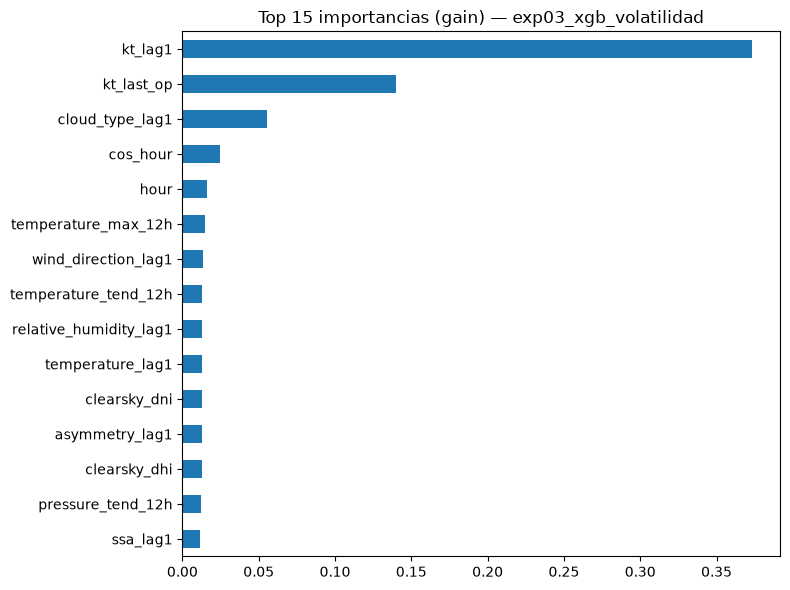

In [4]:
r.plot_importancias(15); plt.tight_layout(); plt.show()

## Series temporales: observado vs modelo vs persistence

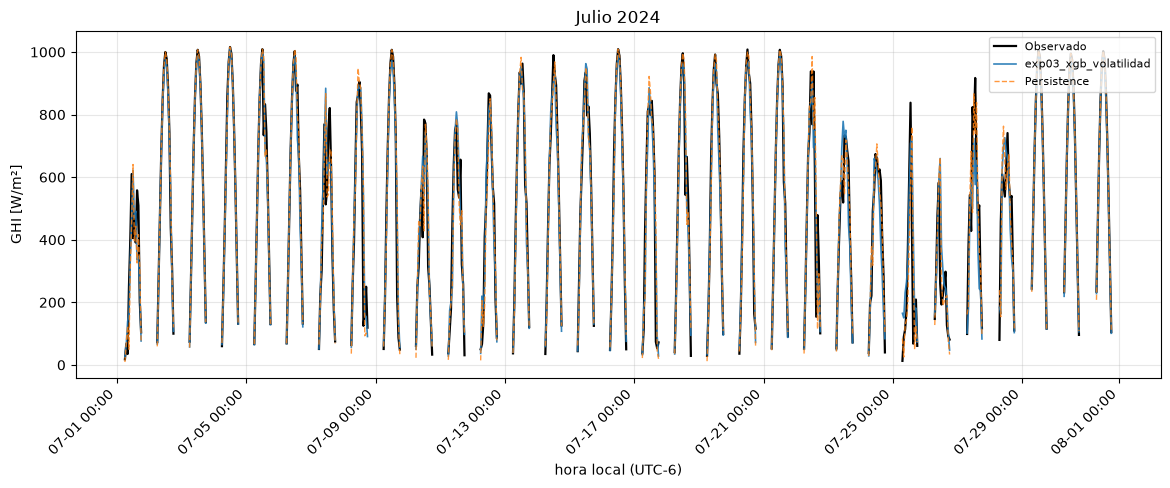

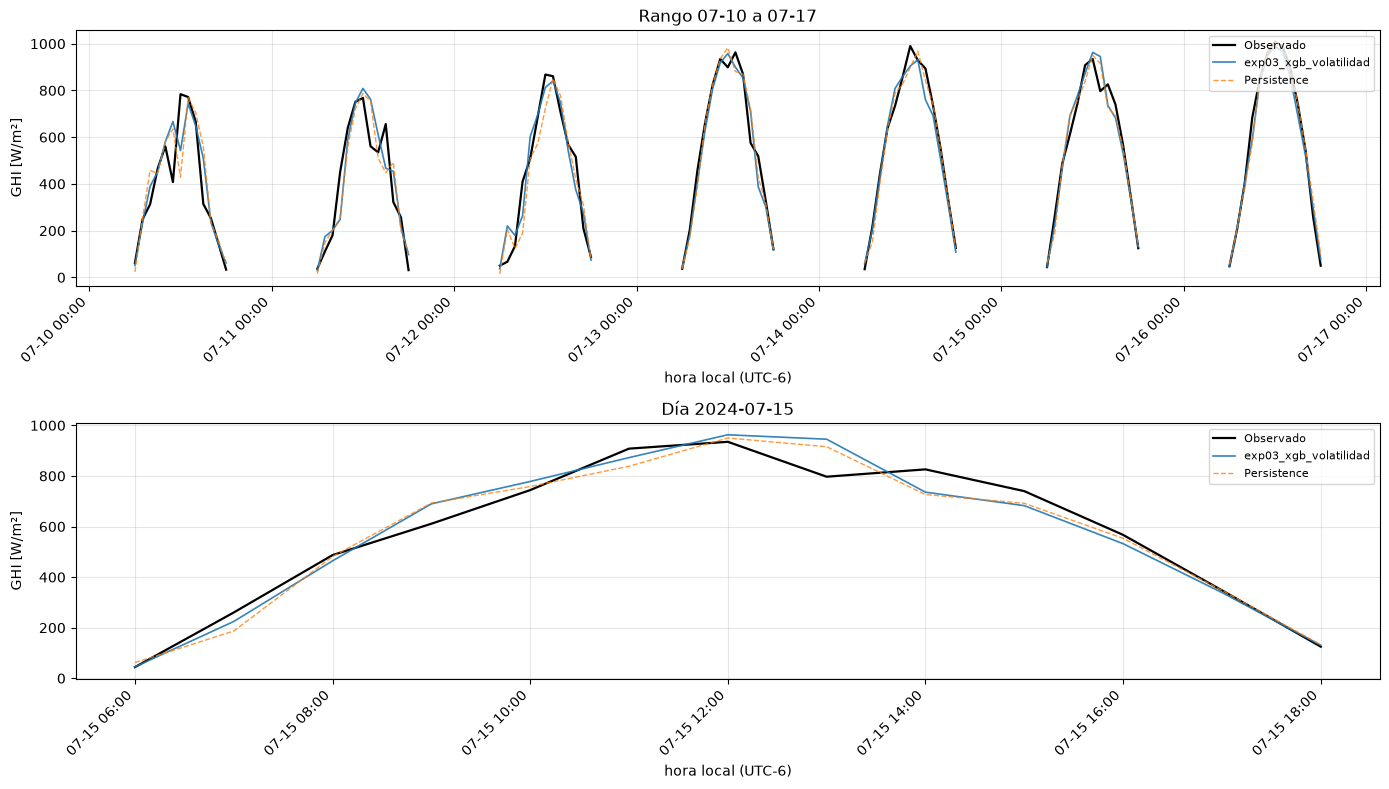

In [5]:
viz = r.visualizador()
viz.serie_temporal(mes=7); plt.title('Julio 2024'); plt.show()
fig, ax = plt.subplots(2, 1, figsize=(14, 8))
viz.serie_temporal(inicio='2024-07-10', fin='2024-07-17', ax=ax[0]); ax[0].set_title('Rango 07-10 a 07-17')
viz.serie_temporal(dia='2024-07-15', ax=ax[1]); ax[1].set_title('Día 2024-07-15')
plt.tight_layout(); plt.show()

## Dispersión predicho vs observado (con R²)

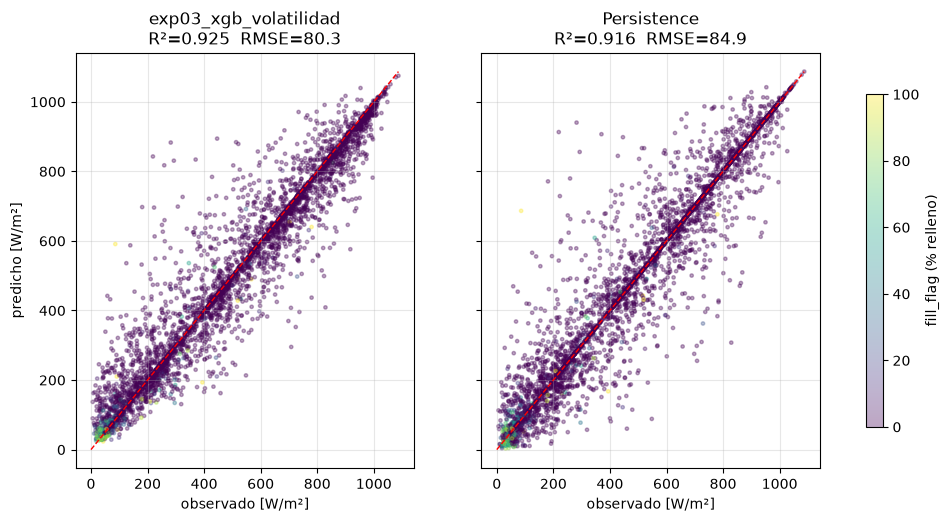

In [6]:
viz.dispersion(); plt.show()

## Días más difíciles

,n_horas,kt_mean,kt_std,fill_frac,rmse_xgb,rmse_persist,nubosidad
dia_local,,,,,,,
2024-06-23,13,0.150,0.140,0.154,125.488,43.918,0.850
2024-02-17,10,0.174,0.096,0.100,57.646,29.522,0.826
2024-06-30,13,0.181,0.141,0.231,108.999,67.981,0.819
2024-06-22,13,0.190,0.094,0.154,85.511,61.612,0.810
2024-01-07,10,0.208,0.078,0.100,30.901,48.365,0.792
2024-02-16,10,0.226,0.090,0.000,73.001,83.443,0.774
2024-12-21,9,0.231,0.149,0.111,64.326,57.386,0.769
2024-04-22,12,0.232,0.144,0.083,76.522,53.374,0.768


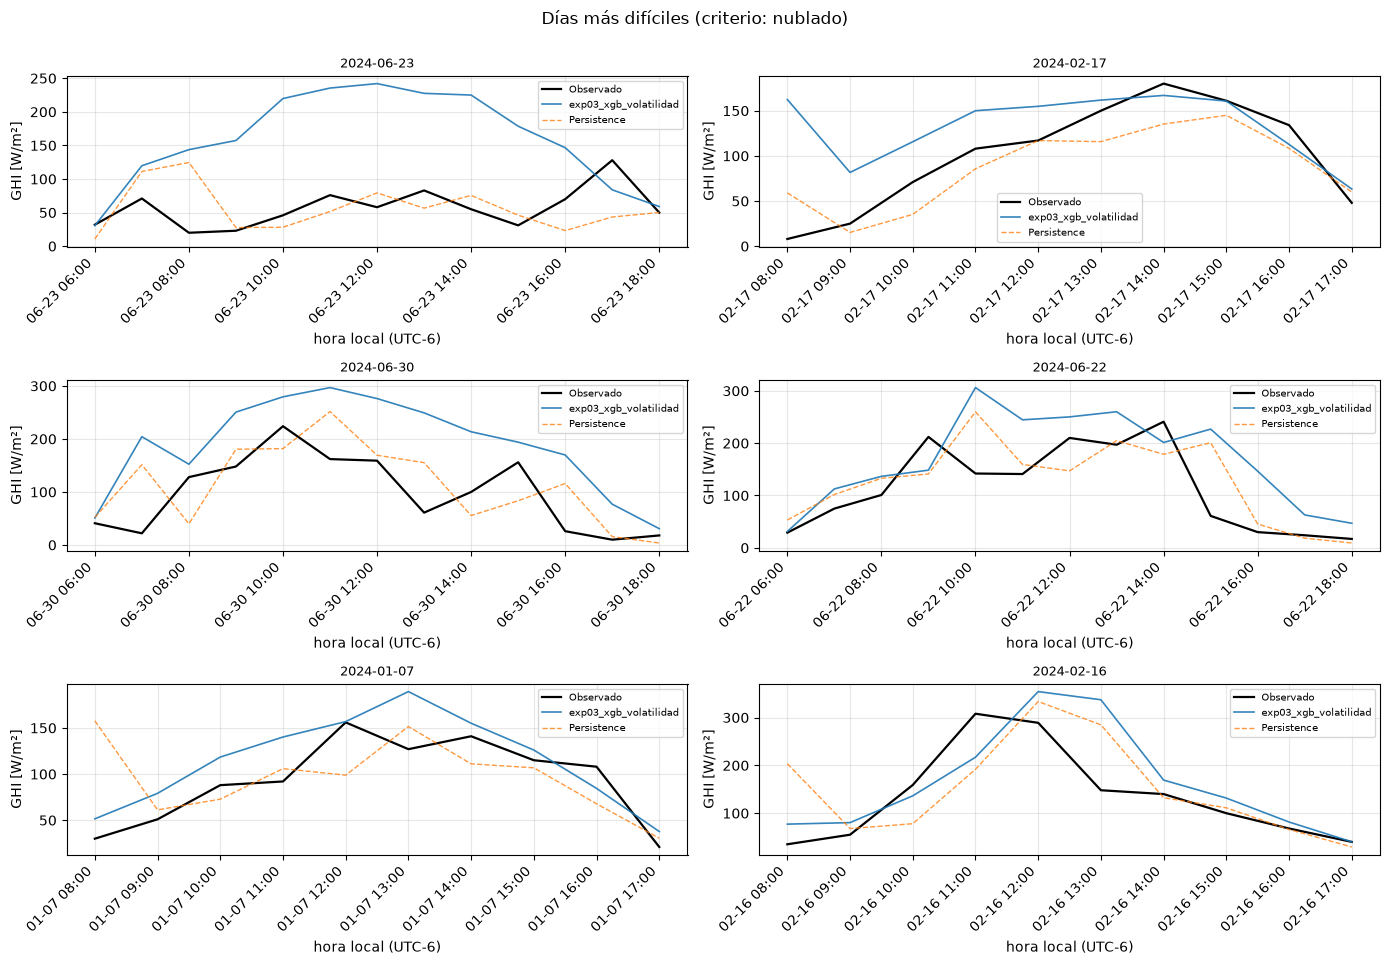

In [7]:
display(viz.dias_dificiles(n=8, criterio='nublado'))
viz.plot_dias_dificiles(n=6, criterio='nublado'); plt.show()